# FakeFez Backend Error Visualization

This notebook visualizes the error characteristics of the FakeFez backend:
- **Qubit errors**: T1, T2, readout errors (node colors)
- **Gate errors**: CZ two-qubit gate errors (edge colors)
- **Heavy-hex topology**: 156 qubits in IBM's heavy-hex layout

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from collections import defaultdict

from qiskit_ibm_runtime.fake_provider import FakeFez

## Load Backend and Extract Error Data

In [2]:
# Initialize FakeFez backend
backend = FakeFez()
target = backend.target
coupling_map = backend.coupling_map

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Number of connections: {len(list(coupling_map.get_edges())) // 2}")

Backend: fake_fez
Number of qubits: 156
Number of connections: 176


In [3]:
# Extract qubit properties
qubit_props = target.qubit_properties
measure_props = target['measure']
sx_props = target['sx']

# Store qubit error data
qubit_data = {}
for i in range(backend.num_qubits):
    t1 = qubit_props[i].t1 * 1e6  # Convert to microseconds
    t2 = qubit_props[i].t2 * 1e6  # Convert to microseconds
    readout_error = measure_props[(i,)].error
    sx_error = sx_props[(i,)].error
    
    qubit_data[i] = {
        't1': t1,
        't2': t2,
        'readout_error': readout_error,
        'sx_error': sx_error
    }

print("Sample qubit data:")
for i in [0, 50, 100, 150]:
    d = qubit_data[i]
    print(f"  Qubit {i}: T1={d['t1']:.1f}μs, T2={d['t2']:.1f}μs, readout={d['readout_error']:.4f}")

Sample qubit data:
  Qubit 0: T1=48.8μs, T2=42.4μs, readout=0.0115
  Qubit 50: T1=145.5μs, T2=130.9μs, readout=0.0039
  Qubit 100: T1=154.3μs, T2=29.2μs, readout=0.0073
  Qubit 150: T1=66.9μs, T2=6.0μs, readout=0.0042


In [4]:
# Extract CZ gate errors (two-qubit gates)
cz_props = target['cz']

edge_errors = {}
for edge, props in cz_props.items():
    # Store as undirected edge (min, max)
    u, v = edge
    edge_key = (min(u, v), max(u, v))
    edge_errors[edge_key] = props.error

print(f"Number of unique edges: {len(edge_errors)}")
print(f"\nCZ error statistics:")
errors = list(edge_errors.values())
print(f"  Min: {min(errors):.6f}")
print(f"  Max: {max(errors):.6f}")
print(f"  Mean: {np.mean(errors):.6f}")
print(f"  Std: {np.std(errors):.6f}")

Number of unique edges: 176

CZ error statistics:
  Min: 0.002139
  Max: 1.000000
  Mean: 0.045112
  Std: 0.194427


## Generate Heavy-Hex Layout Coordinates

FakeFez uses IBM's heavy-hex topology with 156 qubits arranged in a specific pattern.

In [5]:
def generate_heavy_hex_coords(num_qubits=156):
    """
    Generate coordinates for IBM's heavy-hex layout.
    
    The layout consists of:
    - Main rows of 16 qubits each (0-15, 20-35, 40-55, etc.)
    - Vertical connector qubits between rows (16-19, 36-39, etc.)
    """
    coords = {}
    
    # FakeFez has 8 main rows and 7 connector rows
    # Main rows: start at 0, 20, 40, 60, 80, 100, 120, 140
    # Connector rows: start at 16, 36, 56, 76, 96, 116, 136
    
    main_row_starts = [0, 20, 40, 60, 80, 100, 120, 140]
    connector_starts = [16, 36, 56, 76, 96, 116, 136]
    
    y_spacing = 1.5
    x_spacing = 1.0
    
    for row_idx, start in enumerate(main_row_starts):
        y = -row_idx * 2 * y_spacing
        for i in range(16):
            qubit = start + i
            x = i * x_spacing
            coords[qubit] = (x, y)
    
    # Connector qubits (4 per row, positioned at columns 3, 7, 11, 15)
    connector_cols = [3, 7, 11, 15]
    for row_idx, start in enumerate(connector_starts):
        y = -(row_idx * 2 + 1) * y_spacing
        for i, col in enumerate(connector_cols):
            qubit = start + i
            x = col * x_spacing
            coords[qubit] = (x, y)
    
    return coords

coords = generate_heavy_hex_coords()
print(f"Generated coordinates for {len(coords)} qubits")

Generated coordinates for 156 qubits


## Visualization Functions

In [6]:
def create_error_colormap():
    """Create a colormap from blue (low error) to red (high error)."""
    colors = ['#2196F3', '#4CAF50', '#FFEB3B', '#FF9800', '#F44336']
    return LinearSegmentedColormap.from_list('error', colors)


def plot_fez_error_map(
    coords,
    qubit_data,
    edge_errors,
    coupling_map,
    qubit_metric='readout_error',
    figsize=(20, 14),
    node_size=400,
    edge_width=3,
    font_size=7,
    title=None,
    show_colorbar=True
):
    """
    Plot the FakeFez qubit layout with error visualization.
    
    Parameters:
    -----------
    coords : dict
        Qubit ID -> (x, y) coordinates
    qubit_data : dict
        Qubit ID -> {t1, t2, readout_error, sx_error}
    edge_errors : dict
        (qubit1, qubit2) -> CZ gate error
    coupling_map : CouplingMap
        Backend coupling map
    qubit_metric : str
        Which qubit metric to color nodes by: 't1', 't2', 'readout_error', 'sx_error'
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor='#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    # Get error ranges for normalization
    edge_error_values = list(edge_errors.values())
    edge_norm = Normalize(vmin=min(edge_error_values), vmax=max(edge_error_values))
    
    if qubit_metric in ['t1', 't2']:
        # For T1/T2, higher is better, so invert
        qubit_values = [qubit_data[q][qubit_metric] for q in range(len(qubit_data))]
        qubit_norm = Normalize(vmin=min(qubit_values), vmax=max(qubit_values))
        invert_qubit = True
    else:
        # For errors, lower is better
        qubit_values = [qubit_data[q][qubit_metric] for q in range(len(qubit_data))]
        qubit_norm = Normalize(vmin=min(qubit_values), vmax=max(qubit_values))
        invert_qubit = False
    
    cmap = create_error_colormap()
    
    # Draw edges first (so nodes appear on top)
    edges_drawn = set()
    for edge, error in edge_errors.items():
        u, v = edge
        if (u, v) in edges_drawn or (v, u) in edges_drawn:
            continue
        edges_drawn.add((u, v))
        
        x1, y1 = coords[u]
        x2, y2 = coords[v]
        
        color = cmap(edge_norm(error))
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=edge_width, zorder=1)
    
    # Draw nodes
    for qubit, (x, y) in coords.items():
        value = qubit_data[qubit][qubit_metric]
        if invert_qubit:
            # Invert so higher T1/T2 = blue (good)
            color = cmap(1 - qubit_norm(value))
        else:
            color = cmap(qubit_norm(value))
        
        circle = plt.Circle((x, y), 0.35, color=color, ec='white', linewidth=1, zorder=2)
        ax.add_patch(circle)
        
        # Add qubit label
        ax.text(x, y, str(qubit), ha='center', va='center', 
                fontsize=font_size, color='white', fontweight='bold', zorder=3)
    
    # Set axis properties
    ax.set_xlim(-1, 16)
    ax.set_ylim(-22, 2)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Title
    if title is None:
        metric_labels = {
            't1': 'T1 Coherence Time',
            't2': 'T2 Coherence Time',
            'readout_error': 'Readout Error',
            'sx_error': 'SX Gate Error'
        }
        title = f"FakeFez Error Map\nNodes: {metric_labels.get(qubit_metric, qubit_metric)} | Edges: CZ Gate Error"
    
    ax.set_title(title, fontsize=16, color='white', pad=20)
    
    # Add colorbars
    if show_colorbar:
        # Edge error colorbar
        sm_edge = ScalarMappable(norm=edge_norm, cmap=cmap)
        cbar_edge = fig.colorbar(sm_edge, ax=ax, orientation='vertical', 
                                  fraction=0.02, pad=0.02, aspect=30)
        cbar_edge.set_label('CZ Gate Error', color='white', fontsize=10)
        cbar_edge.ax.yaxis.set_tick_params(color='white')
        plt.setp(plt.getp(cbar_edge.ax.axes, 'yticklabels'), color='white')
        
        # Qubit metric colorbar
        sm_qubit = ScalarMappable(norm=qubit_norm, cmap=cmap)
        cbar_qubit = fig.colorbar(sm_qubit, ax=ax, orientation='vertical',
                                   fraction=0.02, pad=0.06, aspect=30)
        unit = 'μs' if qubit_metric in ['t1', 't2'] else ''
        label = f"{qubit_metric.upper()} {unit}" if qubit_metric in ['t1', 't2'] else qubit_metric.replace('_', ' ').title()
        cbar_qubit.set_label(label, color='white', fontsize=10)
        cbar_qubit.ax.yaxis.set_tick_params(color='white')
        plt.setp(plt.getp(cbar_qubit.ax.axes, 'yticklabels'), color='white')
    
    plt.tight_layout()
    return fig, ax

## Visualize Error Maps

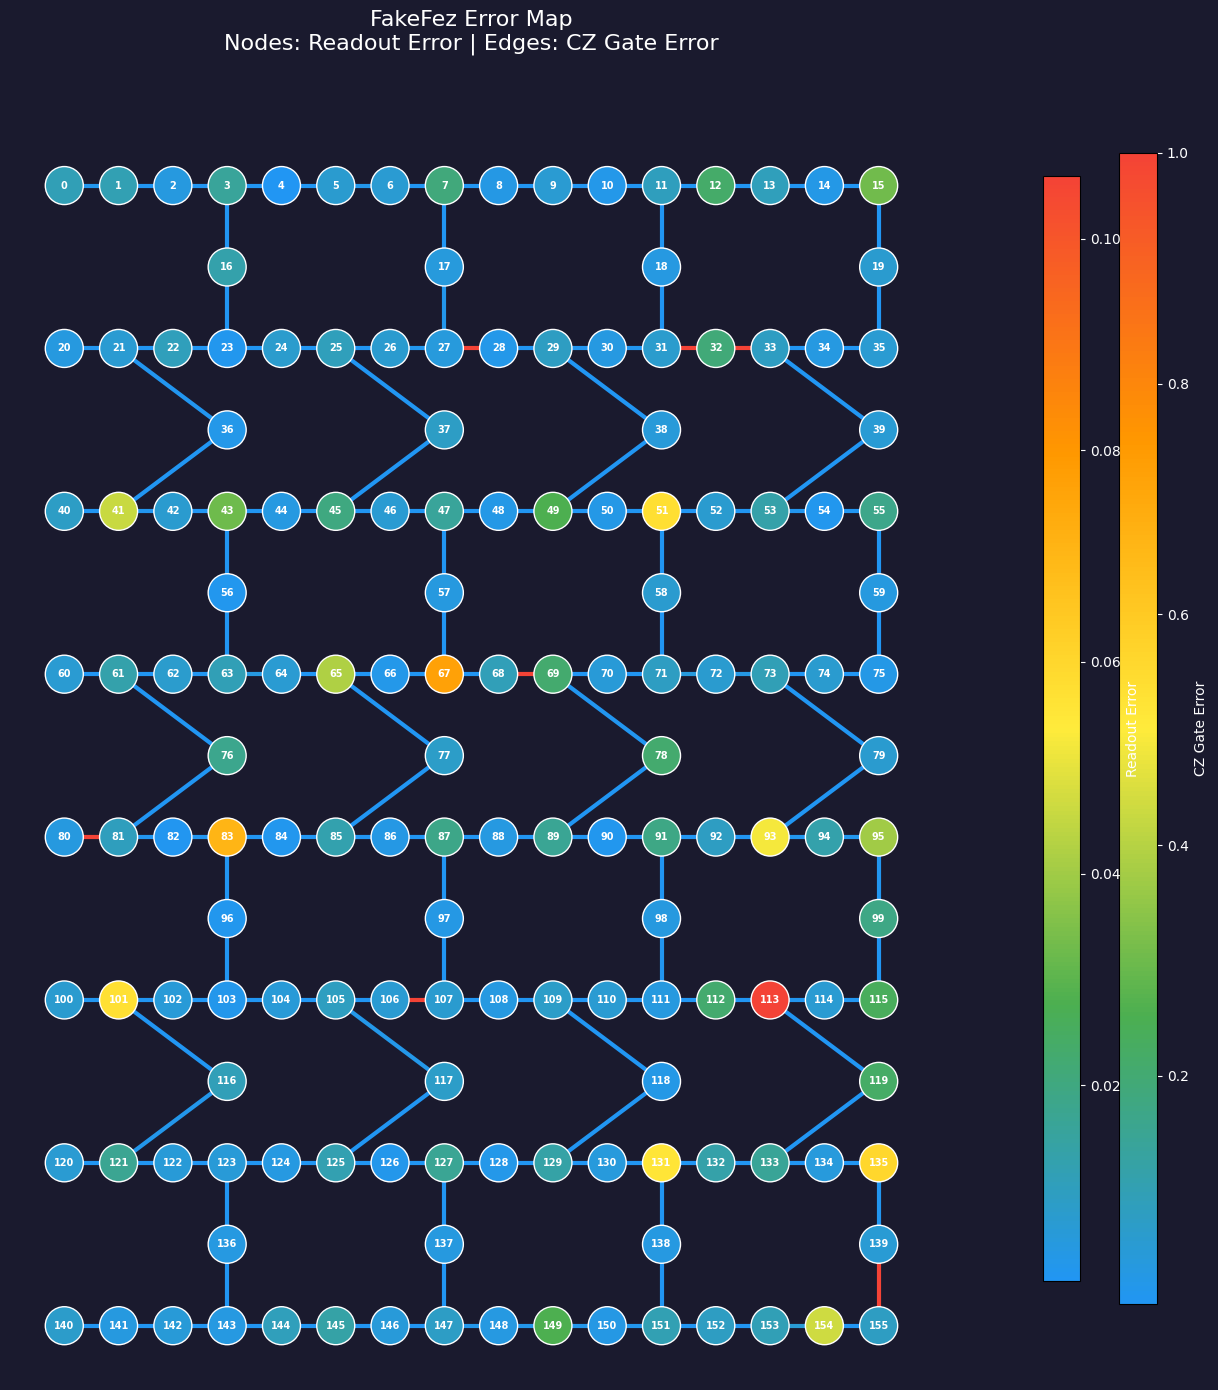

In [7]:
# Plot with readout error coloring
fig, ax = plot_fez_error_map(
    coords=coords,
    qubit_data=qubit_data,
    edge_errors=edge_errors,
    coupling_map=coupling_map,
    qubit_metric='readout_error',
    figsize=(20, 14)
)
plt.show()

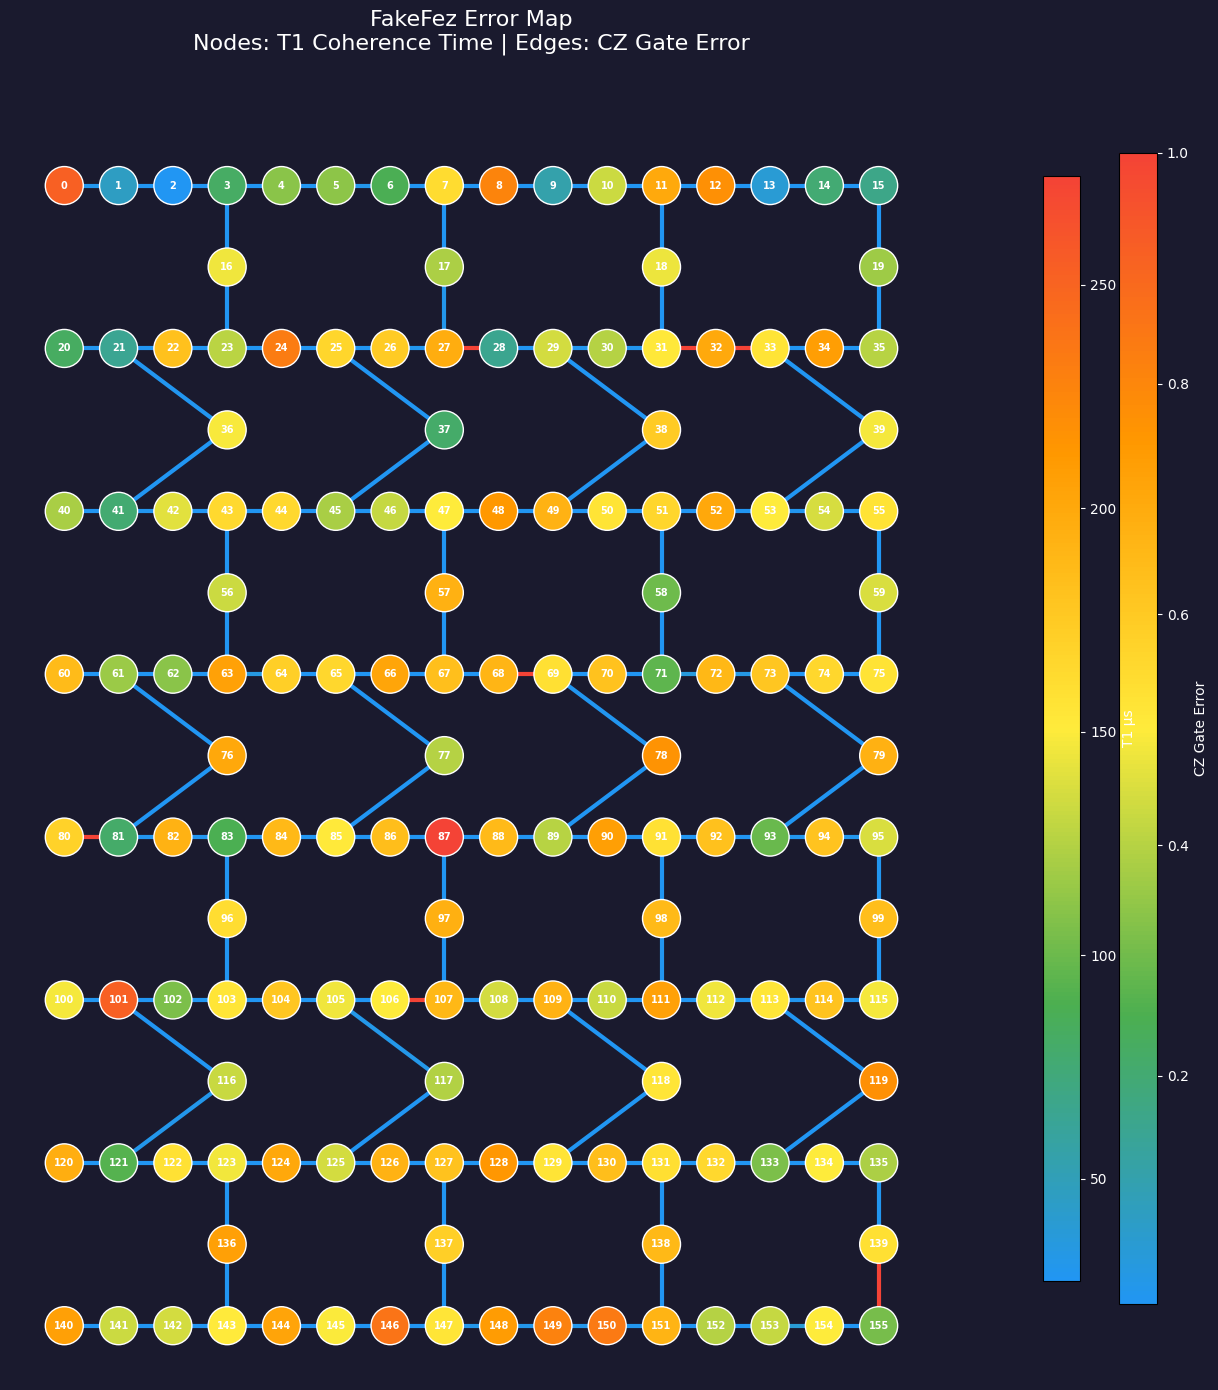

In [8]:
# Plot with T1 coherence coloring
fig, ax = plot_fez_error_map(
    coords=coords,
    qubit_data=qubit_data,
    edge_errors=edge_errors,
    coupling_map=coupling_map,
    qubit_metric='t1',
    figsize=(20, 14)
)
plt.show()

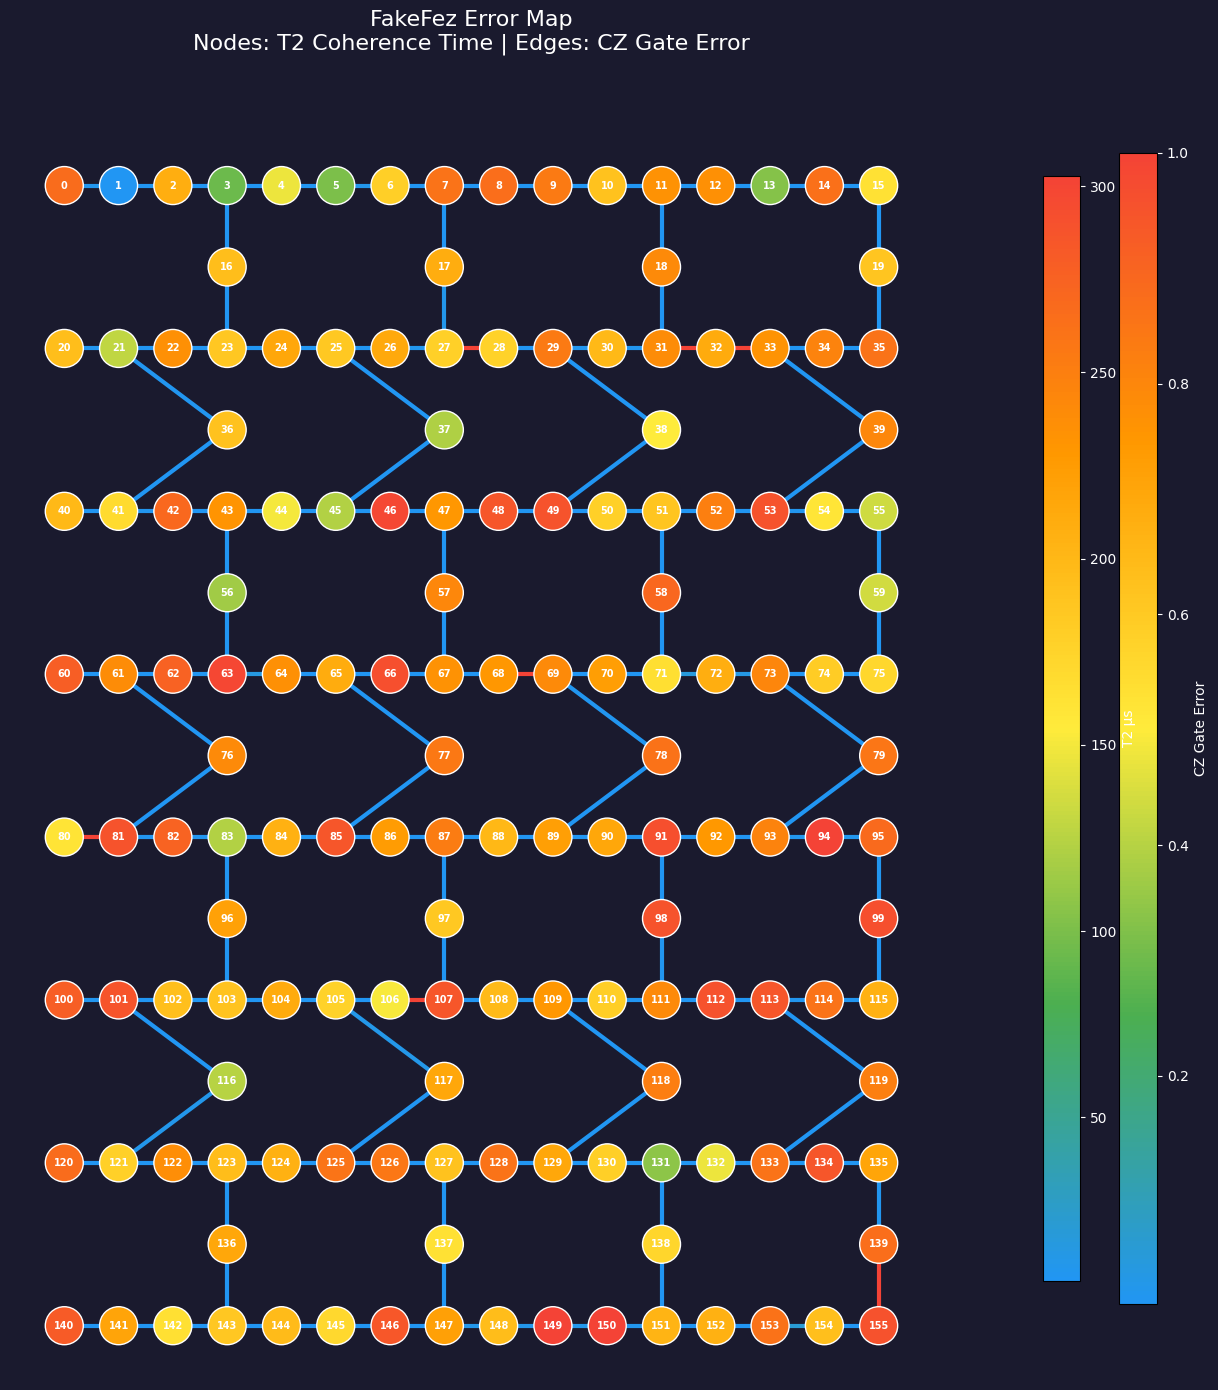

In [9]:
# Plot with T2 coherence coloring
fig, ax = plot_fez_error_map(
    coords=coords,
    qubit_data=qubit_data,
    edge_errors=edge_errors,
    coupling_map=coupling_map,
    qubit_metric='t2',
    figsize=(20, 14)
)
plt.show()

## Highlight Specific Qubits

Plot with specific qubits highlighted (useful for showing your network nodes).

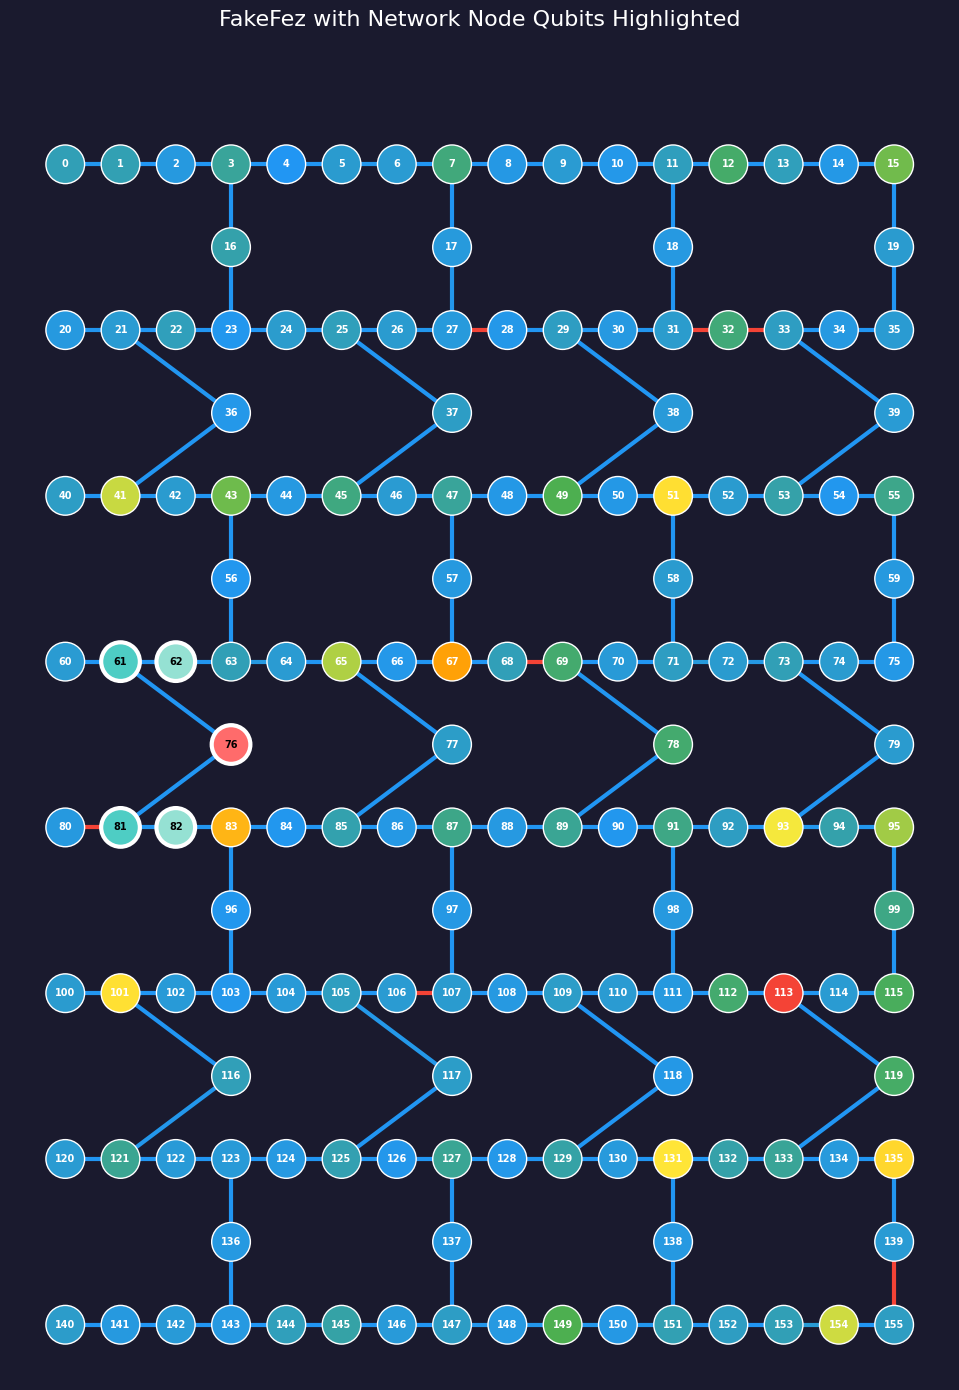

In [10]:
def plot_fez_with_highlights(
    coords,
    qubit_data,
    edge_errors,
    highlight_qubits=None,
    highlight_edges=None,
    qubit_metric='readout_error',
    figsize=(20, 14),
    node_size=400,
    edge_width=3,
    font_size=7,
    title=None
):
    """
    Plot FakeFez with specific qubits and edges highlighted.
    
    Parameters:
    -----------
    highlight_qubits : dict or list
        If dict: {qubit_id: color} for custom colors
        If list: [qubit_ids] highlighted in yellow
    highlight_edges : list
        List of (u, v) edges to highlight
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor='#1a1a2e')
    ax.set_facecolor('#1a1a2e')
    
    # Process highlights
    if highlight_qubits is None:
        highlight_qubits = {}
    elif isinstance(highlight_qubits, list):
        highlight_qubits = {q: '#FFD700' for q in highlight_qubits}  # Gold
    
    if highlight_edges is None:
        highlight_edges = set()
    else:
        highlight_edges = {(min(u, v), max(u, v)) for u, v in highlight_edges}
    
    # Get error ranges for normalization
    edge_error_values = list(edge_errors.values())
    edge_norm = Normalize(vmin=min(edge_error_values), vmax=max(edge_error_values))
    
    qubit_values = [qubit_data[q][qubit_metric] for q in range(len(qubit_data))]
    qubit_norm = Normalize(vmin=min(qubit_values), vmax=max(qubit_values))
    invert_qubit = qubit_metric in ['t1', 't2']
    
    cmap = create_error_colormap()
    
    # Draw edges
    edges_drawn = set()
    for edge, error in edge_errors.items():
        u, v = edge
        if (u, v) in edges_drawn or (v, u) in edges_drawn:
            continue
        edges_drawn.add((u, v))
        
        x1, y1 = coords[u]
        x2, y2 = coords[v]
        
        if (u, v) in highlight_edges or (v, u) in highlight_edges:
            color = '#FF00FF'  # Magenta for highlighted edges
            width = edge_width * 2
            zorder = 1.5
        else:
            color = cmap(edge_norm(error))
            width = edge_width
            zorder = 1
        
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=width, zorder=zorder)
    
    # Draw nodes
    for qubit, (x, y) in coords.items():
        if qubit in highlight_qubits:
            color = highlight_qubits[qubit]
            ec = 'white'
            lw = 3
        else:
            value = qubit_data[qubit][qubit_metric]
            if invert_qubit:
                color = cmap(1 - qubit_norm(value))
            else:
                color = cmap(qubit_norm(value))
            ec = 'white'
            lw = 1
        
        circle = plt.Circle((x, y), 0.35, color=color, ec=ec, linewidth=lw, zorder=2)
        ax.add_patch(circle)
        
        text_color = 'black' if qubit in highlight_qubits else 'white'
        ax.text(x, y, str(qubit), ha='center', va='center', 
                fontsize=font_size, color=text_color, fontweight='bold', zorder=3)
    
    ax.set_xlim(-1, 16)
    ax.set_ylim(-22, 2)
    ax.set_aspect('equal')
    ax.axis('off')
    
    if title:
        ax.set_title(title, fontsize=16, color='white', pad=20)
    
    plt.tight_layout()
    return fig, ax


# Example: Highlight qubits used in config_1 (from your network)
# Node A: data=[76], encoding=[61, 81], ancilla=[62, 82]
# Adjust these to match your actual node configuration
network_qubits = {
    # Node A
    76: '#FF6B6B',   # Data - Red
    61: '#4ECDC4',   # Encoding - Cyan
    81: '#4ECDC4',
    62: '#95E1D3',   # Ancilla - Light green
    82: '#95E1D3',
}

fig, ax = plot_fez_with_highlights(
    coords=coords,
    qubit_data=qubit_data,
    edge_errors=edge_errors,
    highlight_qubits=network_qubits,
    qubit_metric='readout_error',
    title="FakeFez with Network Node Qubits Highlighted"
)
plt.show()

## Error Statistics Summary

In [11]:
def print_error_statistics(qubit_data, edge_errors):
    """Print summary statistics for all error metrics."""
    
    print("="*60)
    print("FAKEFEZ ERROR STATISTICS")
    print("="*60)
    
    # Qubit metrics
    metrics = ['t1', 't2', 'readout_error', 'sx_error']
    units = ['μs', 'μs', '', '']
    
    print("\n--- Qubit Properties ---")
    for metric, unit in zip(metrics, units):
        values = [qubit_data[q][metric] for q in qubit_data]
        print(f"\n{metric.upper()}:")
        print(f"  Min:    {min(values):.4f} {unit}")
        print(f"  Max:    {max(values):.4f} {unit}")
        print(f"  Mean:   {np.mean(values):.4f} {unit}")
        print(f"  Median: {np.median(values):.4f} {unit}")
        print(f"  Std:    {np.std(values):.4f} {unit}")
    
    # Edge metrics
    print("\n--- CZ Gate Errors ---")
    errors = list(edge_errors.values())
    print(f"  Min:    {min(errors):.6f}")
    print(f"  Max:    {max(errors):.6f}")
    print(f"  Mean:   {np.mean(errors):.6f}")
    print(f"  Median: {np.median(errors):.6f}")
    print(f"  Std:    {np.std(errors):.6f}")
    
    # Find best and worst qubits
    print("\n--- Best/Worst Qubits ---")
    
    # Best T1
    best_t1 = max(qubit_data.items(), key=lambda x: x[1]['t1'])
    worst_t1 = min(qubit_data.items(), key=lambda x: x[1]['t1'])
    print(f"  Best T1:  Qubit {best_t1[0]} ({best_t1[1]['t1']:.2f} μs)")
    print(f"  Worst T1: Qubit {worst_t1[0]} ({worst_t1[1]['t1']:.2f} μs)")
    
    # Best readout
    best_ro = min(qubit_data.items(), key=lambda x: x[1]['readout_error'])
    worst_ro = max(qubit_data.items(), key=lambda x: x[1]['readout_error'])
    print(f"  Best Readout:  Qubit {best_ro[0]} ({best_ro[1]['readout_error']:.6f})")
    print(f"  Worst Readout: Qubit {worst_ro[0]} ({worst_ro[1]['readout_error']:.6f})")
    
    # Best/worst edges
    print("\n--- Best/Worst Edges ---")
    best_edge = min(edge_errors.items(), key=lambda x: x[1])
    worst_edge = max(edge_errors.items(), key=lambda x: x[1])
    print(f"  Best CZ:  {best_edge[0]} (error: {best_edge[1]:.6f})")
    print(f"  Worst CZ: {worst_edge[0]} (error: {worst_edge[1]:.6f})")

print_error_statistics(qubit_data, edge_errors)

FAKEFEZ ERROR STATISTICS

--- Qubit Properties ---

T1:
  Min:    27.1485 μs
  Max:    274.3943 μs
  Mean:   145.2556 μs
  Median: 144.8553 μs
  Std:    44.9576 μs

T2:
  Min:    5.9857 μs
  Max:    302.7909 μs
  Mean:   90.4591 μs
  Median: 87.9507 μs
  Std:    52.7244 μs

READOUT_ERROR:
  Min:    0.0015 
  Max:    0.1060 
  Mean:   0.0132 
  Median: 0.0076 
  Std:    0.0154 

SX_ERROR:
  Min:    0.0001 
  Max:    0.0025 
  Mean:   0.0003 
  Median: 0.0002 
  Std:    0.0002 

--- CZ Gate Errors ---
  Min:    0.002139
  Max:    1.000000
  Mean:   0.045112
  Median: 0.003903
  Std:    0.194427

--- Best/Worst Qubits ---
  Best T1:  Qubit 2 (274.39 μs)
  Worst T1: Qubit 87 (27.15 μs)
  Best Readout:  Qubit 4 (0.001465)
  Worst Readout: Qubit 113 (0.105957)

--- Best/Worst Edges ---
  Best CZ:  (22, 23) (error: 0.002139)
  Worst CZ: (27, 28) (error: 1.000000)


## Error Distribution Histograms

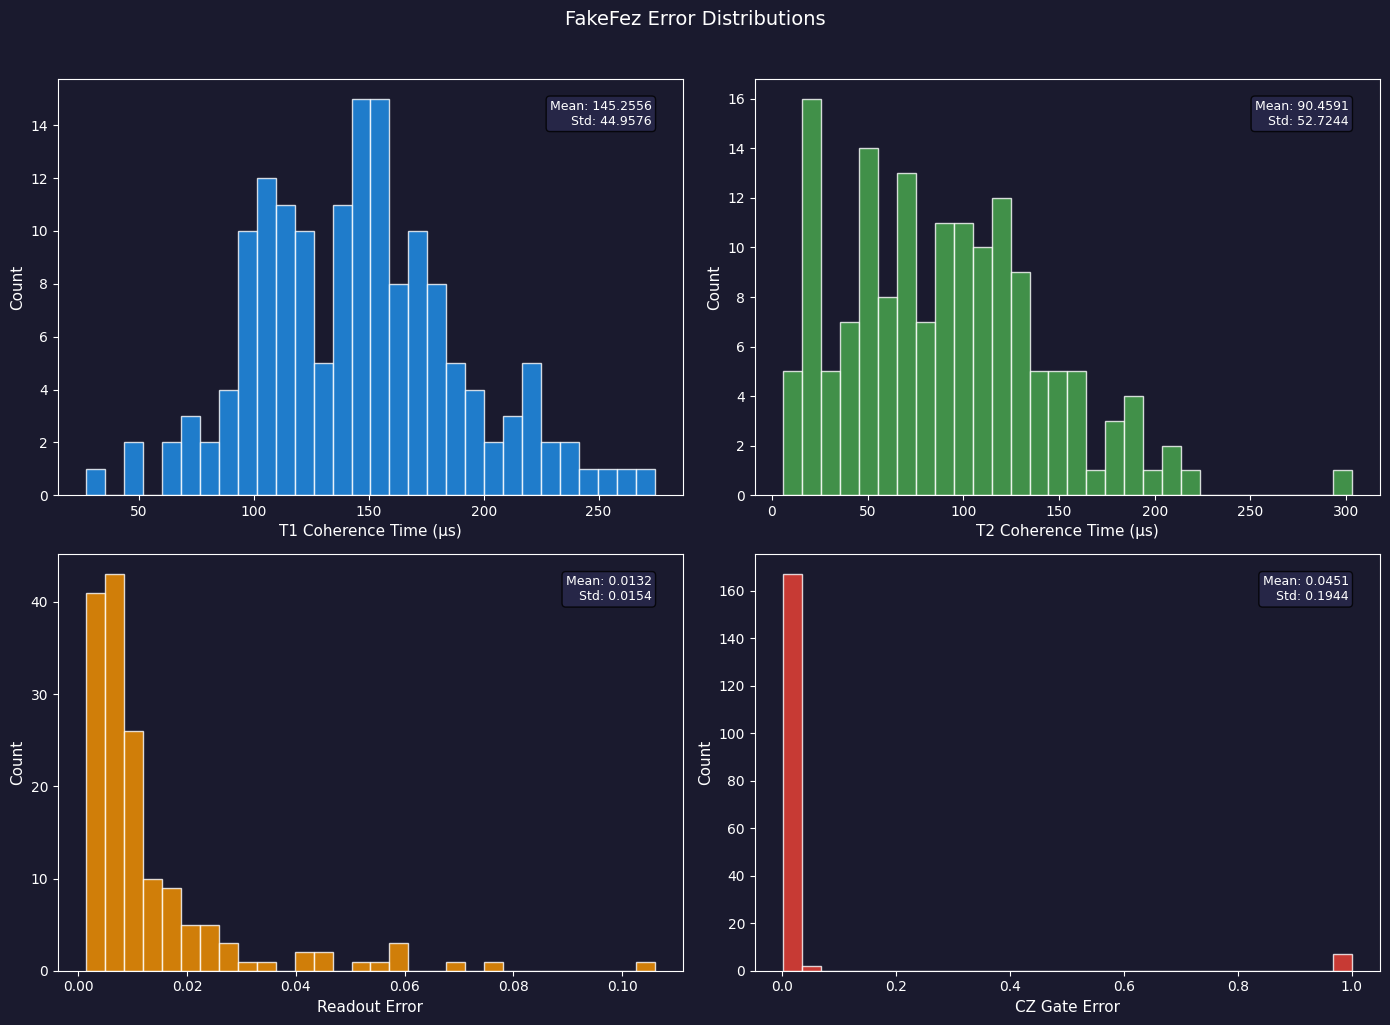

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#1a1a2e')

metrics = [
    ('t1', 'T1 Coherence Time (μs)', '#2196F3'),
    ('t2', 'T2 Coherence Time (μs)', '#4CAF50'),
    ('readout_error', 'Readout Error', '#FF9800'),
    ('CZ', 'CZ Gate Error', '#F44336')
]

for ax, (metric, label, color) in zip(axes.flat, metrics):
    ax.set_facecolor('#1a1a2e')
    
    if metric == 'CZ':
        values = list(edge_errors.values())
    else:
        values = [qubit_data[q][metric] for q in qubit_data]
    
    ax.hist(values, bins=30, color=color, edgecolor='white', alpha=0.8)
    ax.set_xlabel(label, color='white', fontsize=11)
    ax.set_ylabel('Count', color='white', fontsize=11)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('white')
    
    # Add statistics
    stats_text = f'Mean: {np.mean(values):.4f}\nStd: {np.std(values):.4f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=9, color='white', verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='#2a2a4e', alpha=0.8))

fig.suptitle('FakeFez Error Distributions', fontsize=14, color='white', y=1.02)
plt.tight_layout()
plt.show()

## Interactive: Select Qubits to Analyze

In [13]:
def analyze_qubit_region(qubit_ids, qubit_data, edge_errors):
    """
    Analyze error properties for a specific set of qubits.
    """
    print(f"\nAnalyzing qubits: {qubit_ids}")
    print("="*50)
    
    # Qubit properties
    print("\nQubit Properties:")
    print(f"{'Qubit':<8} {'T1 (μs)':<12} {'T2 (μs)':<12} {'Readout':<12} {'SX Error':<12}")
    print("-"*56)
    
    for q in qubit_ids:
        d = qubit_data[q]
        print(f"{q:<8} {d['t1']:<12.2f} {d['t2']:<12.2f} {d['readout_error']:<12.6f} {d['sx_error']:<12.6f}")
    
    # Relevant edges
    print("\nRelevant CZ Gate Errors:")
    qubit_set = set(qubit_ids)
    for (u, v), error in sorted(edge_errors.items()):
        if u in qubit_set or v in qubit_set:
            in_region = "*" if (u in qubit_set and v in qubit_set) else " "
            print(f"  {in_region} ({u}, {v}): {error:.6f}")

# Example: Analyze a region of qubits
analyze_qubit_region([61, 62, 76, 77, 81, 82], qubit_data, edge_errors)


Analyzing qubits: [61, 62, 76, 77, 81, 82]

Qubit Properties:
Qubit    T1 (μs)      T2 (μs)      Readout      SX Error    
--------------------------------------------------------
61       185.15       70.81        0.012939     0.000356    
62       190.51       33.57        0.007812     0.000309    
76       101.38       67.55        0.017822     0.000234    
77       176.75       53.06        0.008545     0.000197    
81       222.09       20.32        0.010254     0.000150    
82       108.74       34.26        0.002197     0.000418    

Relevant CZ Gate Errors:
    (60, 61): 0.003587
  * (61, 62): 0.003492
  * (61, 76): 0.003581
    (62, 63): 0.007411
    (65, 77): 0.004525
  * (76, 81): 0.002227
    (77, 85): 0.003426
    (80, 81): 1.000000
  * (81, 82): 0.007996
    (82, 83): 0.009349


## Save Figure

Saved: fakefez_error_map.png


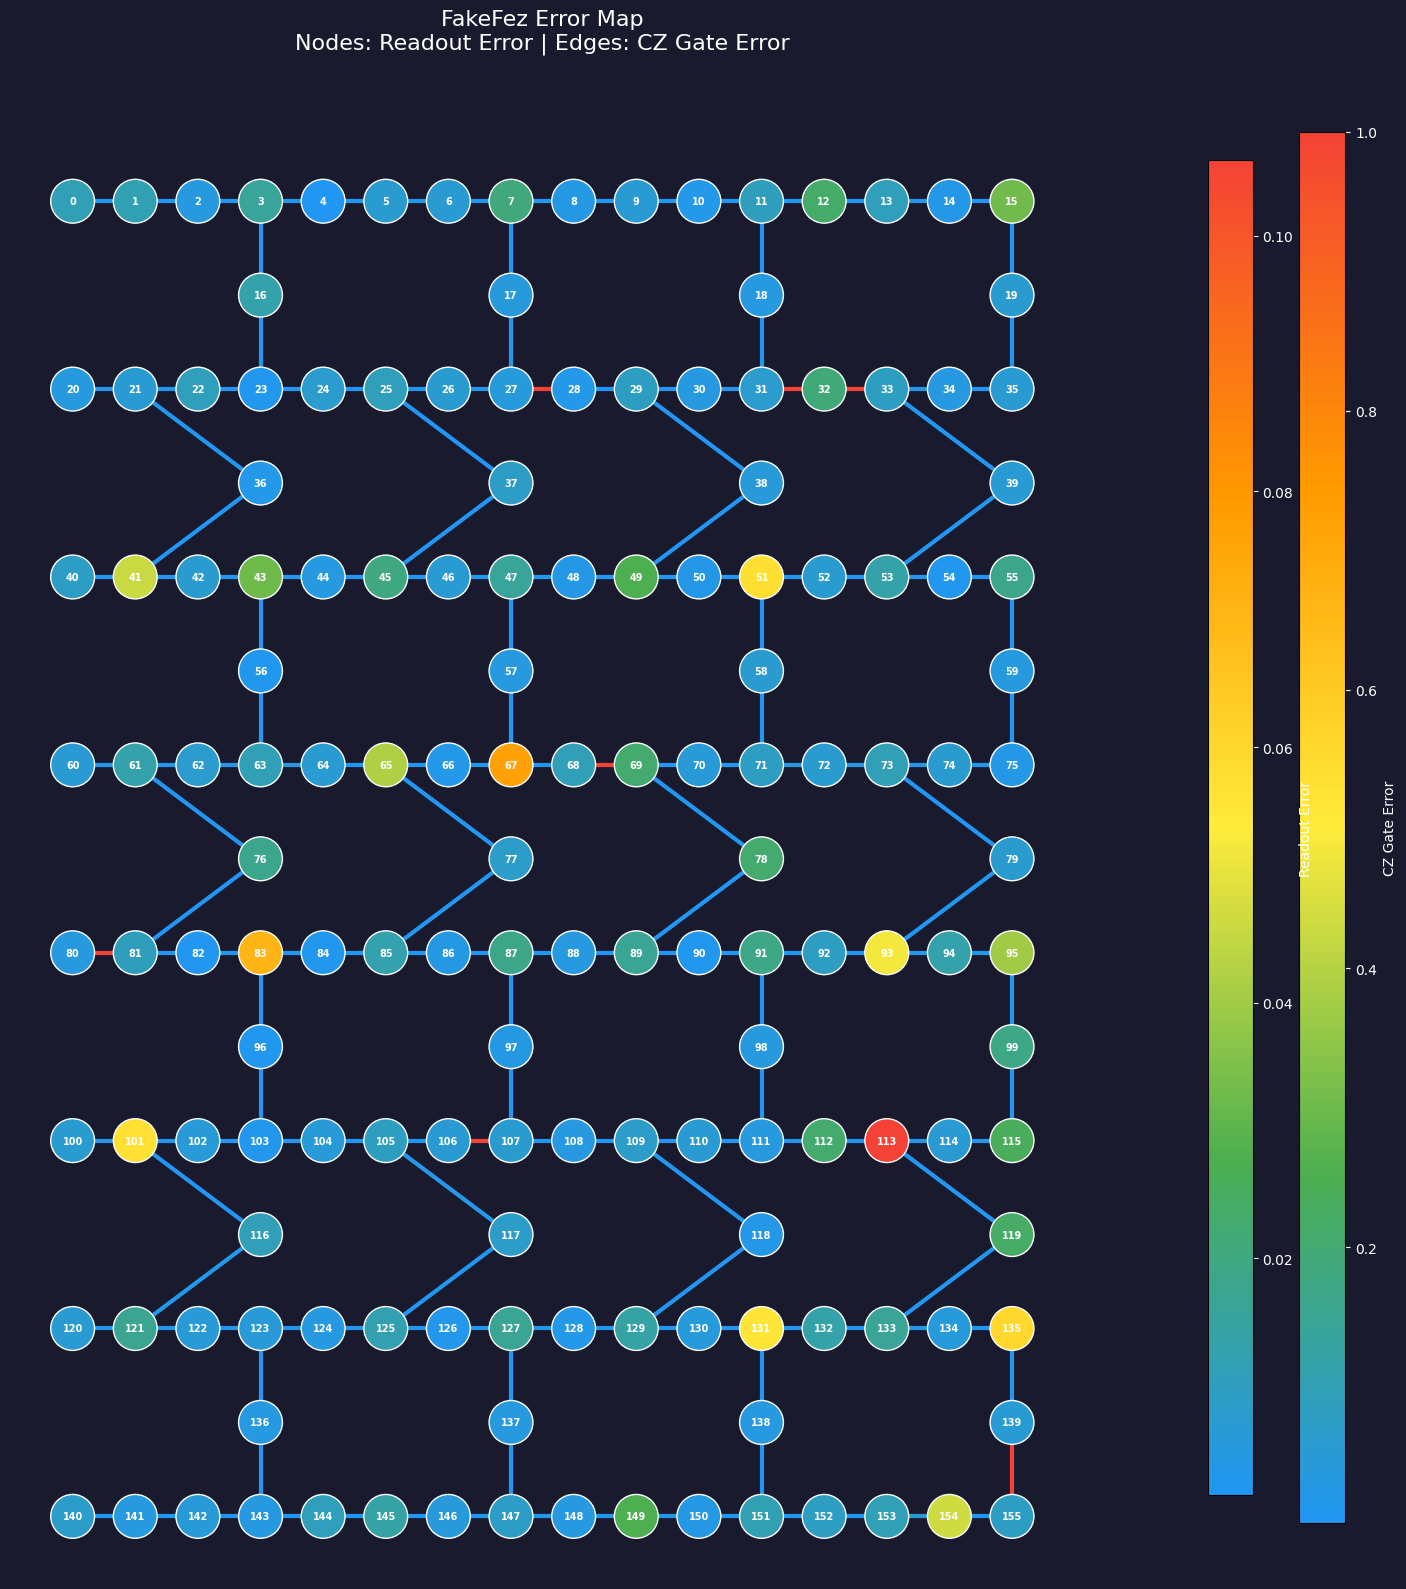

In [14]:
# Generate and save high-resolution figure
fig, ax = plot_fez_error_map(
    coords=coords,
    qubit_data=qubit_data,
    edge_errors=edge_errors,
    coupling_map=coupling_map,
    qubit_metric='readout_error',
    figsize=(24, 16)
)

# Save as PNG
fig.savefig('fakefez_error_map.png', dpi=300, bbox_inches='tight', 
            facecolor='#1a1a2e', edgecolor='none')
print("Saved: fakefez_error_map.png")

plt.show()